In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
print("Pakage ara installed Succesfully")

Pakage ara installed Succesfully


In [2]:
data=load_iris()
X=data.data
y=data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

In [3]:
rf=RandomForestClassifier(
    n_estimators=50,  #No of trees
    max_depth=None,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)


RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [4]:
y_pred=rf.predict(X_test)

In [5]:
print('='*100)
print("Random Forest Perfomance")
print(f"Accuracy Score :{accuracy_score(y_test,y_pred)}")
print(f"Classification Report:\n{classification_report(y_test,y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")

Random Forest Perfomance
Accuracy Score :0.8888888888888888
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.78      0.93      0.85        15
           2       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]


In [6]:
from sklearn.datasets import load_breast_cancer

In [7]:
data_Cancer=load_breast_cancer()
X=data_Cancer.data
y=data_Cancer.target
feature_name=data_Cancer.feature_names
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42,stratify=y)

In [8]:
rf=RandomForestClassifier(
    n_estimators=50,  #No of trees
    max_depth=None,
    bootstrap=True,
    criterion='entropy',

    random_state=42,
    n_jobs=-1
)
# rf.fit(X_train,y_train)

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Model banana
rf = RandomForestClassifier()

# Training
rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)

In [10]:
print('='*100)
print("Random Forest Perfomance")
print(f"Accuracy Score :{accuracy_score(y_test,y_pred)}")
print(f"Classification Report:\n{classification_report(y_test,y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")

Random Forest Perfomance
Accuracy Score :0.9111111111111111
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


In [11]:
print('\nFeature Importance ')

for name,imp in sorted(
    zip(feature_name,rf.feature_importances_),
    key=lambda x:x[1],
    reverse=True
)[:5]:

    print(f"{name}:{imp}")


Feature Importance 
mean area:0.4778207528925705
mean perimeter:0.4058303329499469
mean radius:0.08952333323950673
mean texture:0.02682558091797578


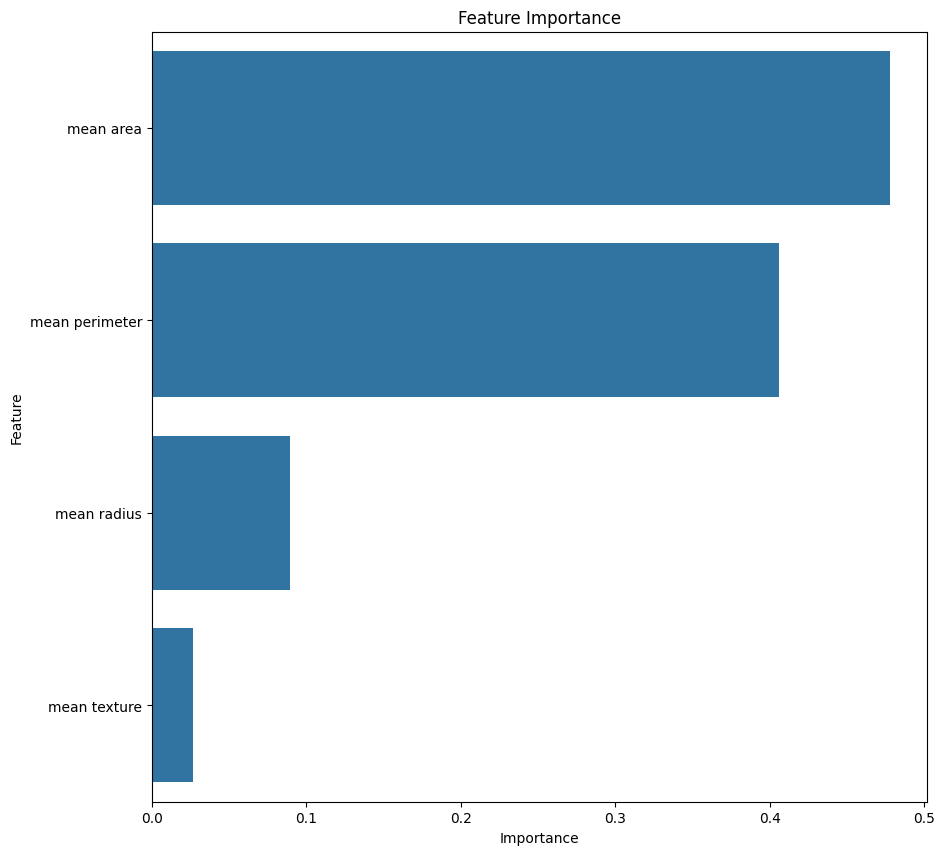

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure we are using the correct features for the model currently in memory
# The error happened because feature_name (30) didn't match rf.feature_importances_ (4)
importances = rf.feature_importances_

# Using the first N feature names that match the model's feature count
current_feature_names = feature_name[:len(importances)]

# Feature importance dataframe
feature_imp = pd.DataFrame({
    'Feature': current_feature_names,
    'Importance': importances
})

# Sort values
feature_imp = feature_imp.sort_values(
    by='Importance',
    ascending=False
)

# Plot size
plt.figure(figsize=(10, 10))

# Seaborn barplot
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_imp
)

# Title
plt.title("Feature Importance")

# Show plot
plt.show()

In [13]:
rf=RandomForestClassifier(
    n_estimators=50,  #No of trees
    max_depth=None,
    bootstrap=True,
    criterion='entropy',
    oob_score=True,

    random_state=42,
    n_jobs=-1
)
rf.fit(X,y)

RandomForestClassifier(criterion='entropy', n_estimators=50, n_jobs=-1,
                       oob_score=True, random_state=42)

In [14]:
oob_accouracy=rf.oob_score_
oob_error=1-oob_accouracy
print(f"OOB Accuracy:{oob_accouracy:.4f}")
print(f"OOB Error:{oob_error:.4f}")

OOB Accuracy:0.9561
OOB Error:0.0439


In [15]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [16]:
data=load_breast_cancer()
X=data.data
y=data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42,stratify=y)

In [17]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [18]:
rf=RandomForestClassifier(random_state=42,n_jobs=-1)
grid_search=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1,verbose=2)
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=2)

In [19]:
best_model=grid_search.best_estimator_
y_pred=best_model.predict(X_test)
print("="*100)
print("Best Model Performance")

for k ,v in grid_search.best_params_.items():
    print(f"{k}:{v}")


print(f"Accuracy Score:{accuracy_score(y_test,y_pred)}")
print(f"Classification Report:\n{classification_report(y_test,y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")

Best Model Performance
max_depth:None
min_samples_leaf:4
min_samples_split:10
n_estimators:50
Accuracy Score:0.9414893617021277
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        70
           1       0.95      0.96      0.95       118

    accuracy                           0.94       188
   macro avg       0.94      0.94      0.94       188
weighted avg       0.94      0.94      0.94       188

Confusion Matrix:
[[ 64   6]
 [  5 113]]


RandomForest Small Project


In [20]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = load_iris()
X = data.data
y = data.target
feature_name = data.feature_names
class_name = data.target_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples : {X_test.shape[0]}")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None, # Changed from True to None
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Corrected the typo 'accoracy_score' to 'accuracy_score'
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("="*100)
print("Random Forest Performance")
print(f"Accuracy Score: {round(acc, 4)}")
print(f"Confusion Matrix:\n{cm}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Training Samples : 112
Testing Samples : 38
Random Forest Performance
Accuracy Score: 0.9211
Confusion Matrix:
[[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.86      0.92      0.89        13
           2       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



In [21]:
best_acc=0
best_n=None

for n in [20,30,50,100]:
  model=RandomForestClassifier(
      n_estimators=n,
      random_state=42

  )
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  acc_n=accuracy_score(y_test,y_pred)
  print(f"Accuracy Score for n={n} : {round(acc_n,4)}")

  if acc_n>best_acc:
    best_acc=acc_n
    best_n=n



print(f"\nBest N  Estimators is selected {best_n}")


Accuracy Score for n=20 : 0.8947
Accuracy Score for n=30 : 0.8947
Accuracy Score for n=50 : 0.9211
Accuracy Score for n=100 : 0.9211

Best N  Estimators is selected 50


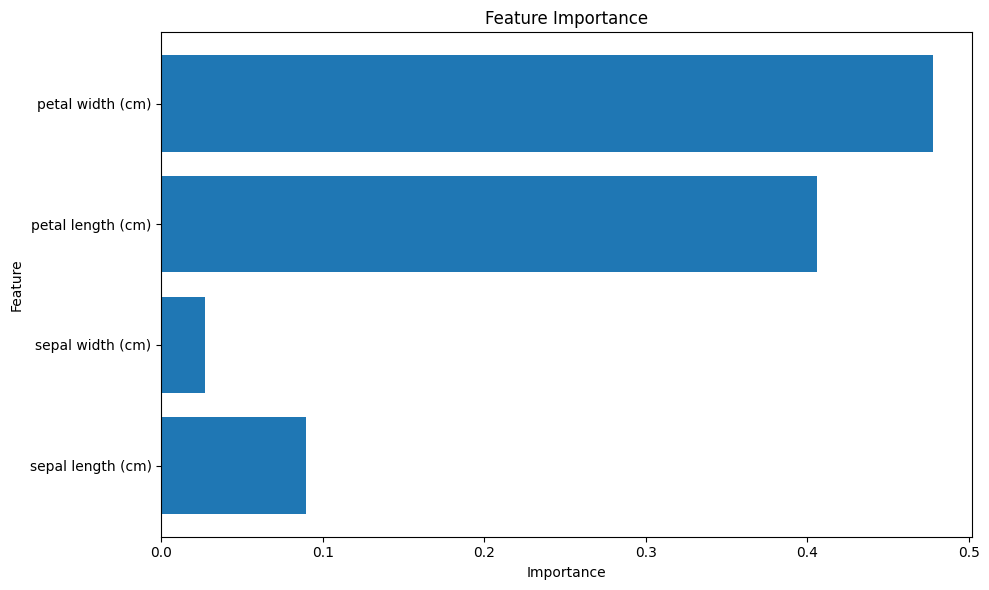

In [22]:
#-----------------------------
# Feature Importance
#-----------------------------
importance=rf.feature_importances_
idx=np.argmax(importances)


plt.figure(figsize=(10,6))
plt.barh(feature_name,importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# 1. Data load kar rahe hain (California Housing)
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

# 2. Data ki pehli 5 rows dekhna
print("--- Data Table (First 5 Rows) ---")
print(df.head())

# 3. Data ki basic information (Columns, Data types, Missing values)
print("\n--- Data Info ---")
print(df.info())

--- Data Table (First 5 Rows) ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3  

In [24]:
np.random.seed(42)
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [25]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


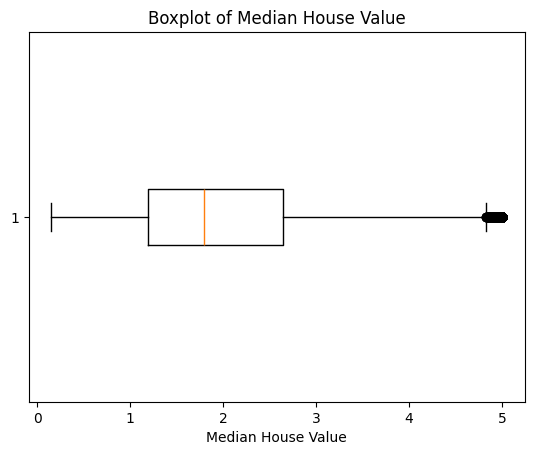

In [26]:
plt.boxplot(x=df['MedHouseVal'], vert=False)
plt.title('Boxplot of Median House Value')
plt.xlabel('Median House Value')
plt.show()

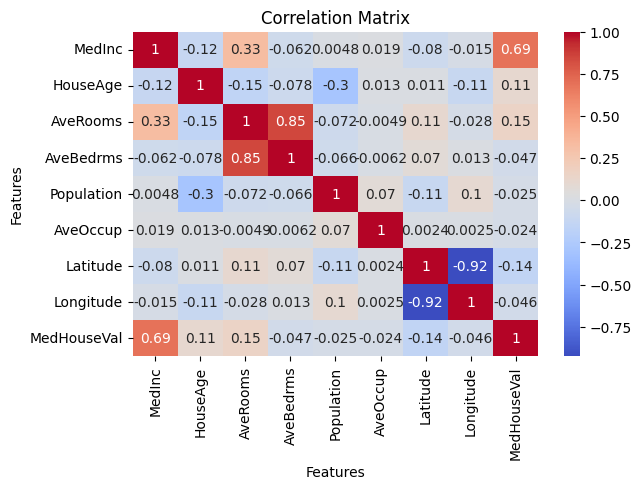

In [27]:
coor_matrix=df.corr()
sns.heatmap(coor_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

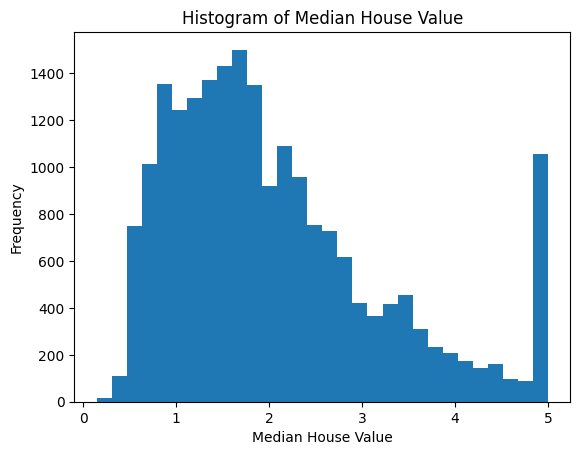

In [28]:
plt.hist(df['MedHouseVal'],bins=30)
plt.title('Histogram of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

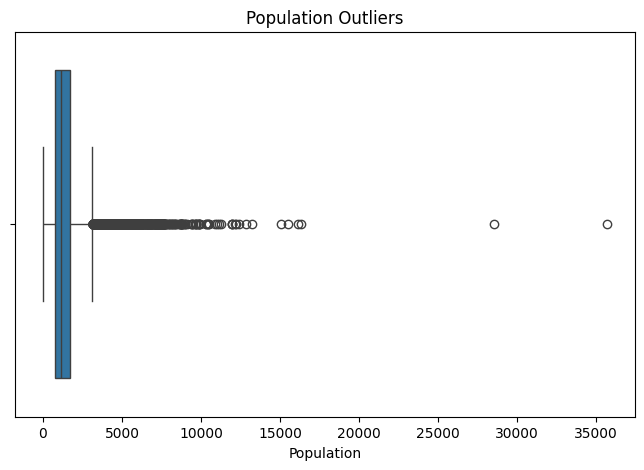

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Population'])

plt.title("Population Outliers")
plt.show()

In [30]:
Q1 = df['Population'].quantile(0.25)
Q3 = df['Population'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-620.0
3132.0


In [31]:
df = df[
    (df['Population'] >= lower) &
    (df['Population'] <= upper)
]

In [32]:
print(df.shape)

print(df.shape)

(19444, 9)
(19444, 9)


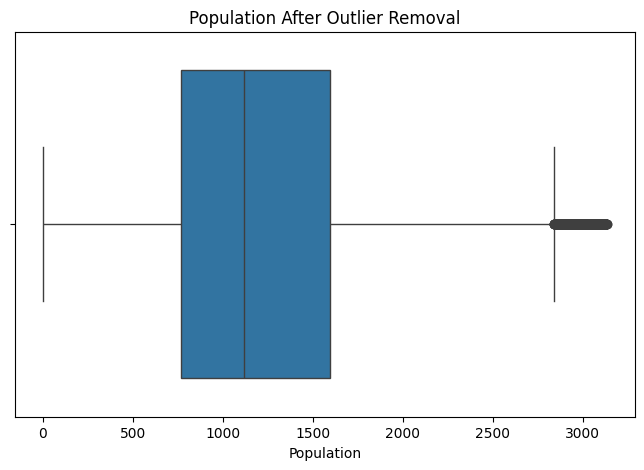

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Population'])

plt.title("Population After Outlier Removal")

plt.show()

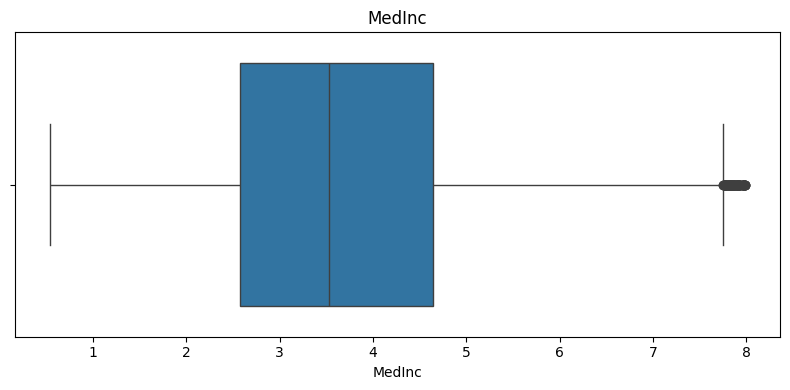

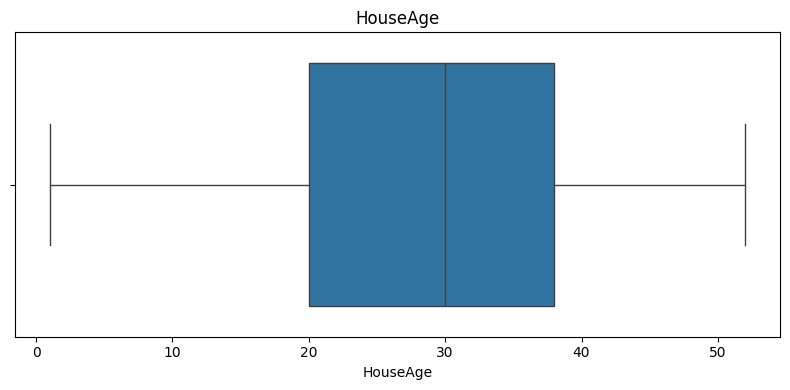

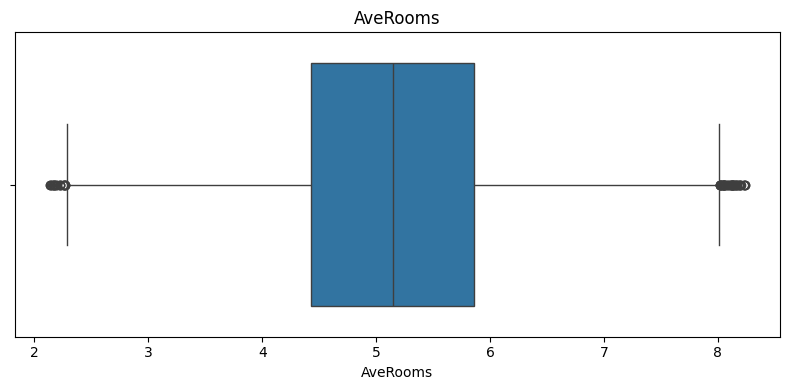

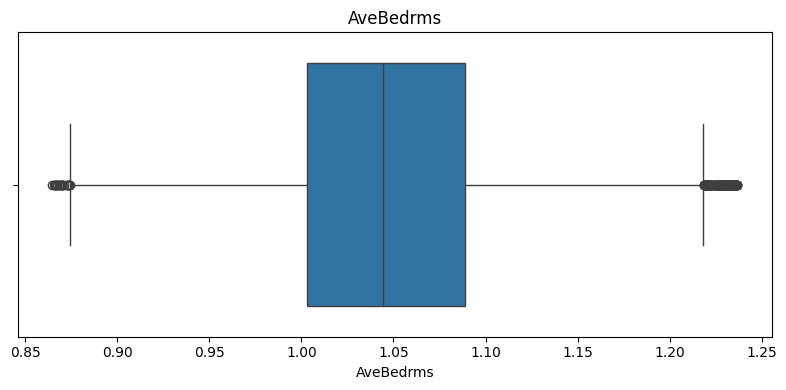

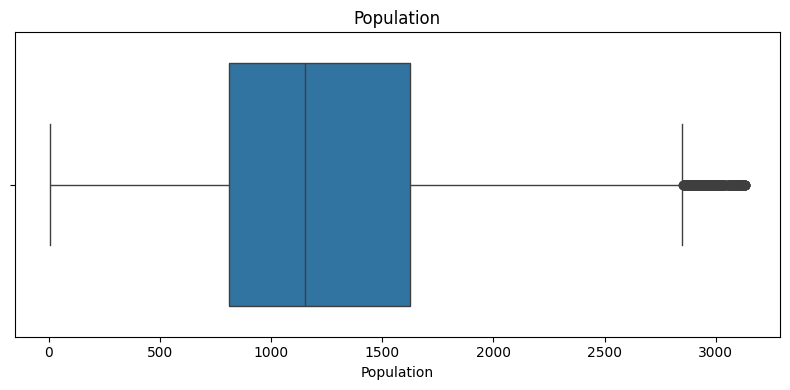

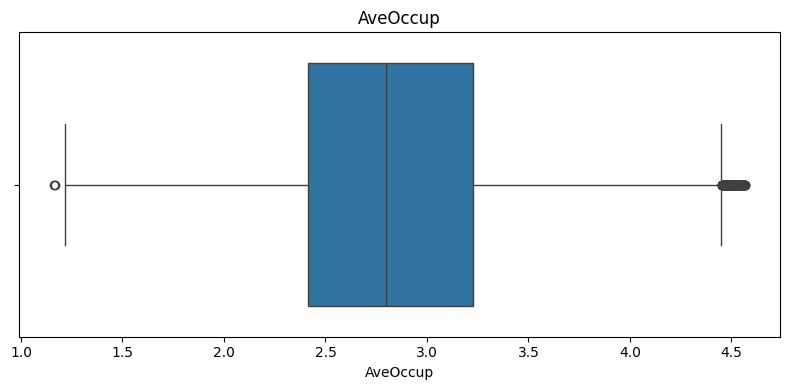

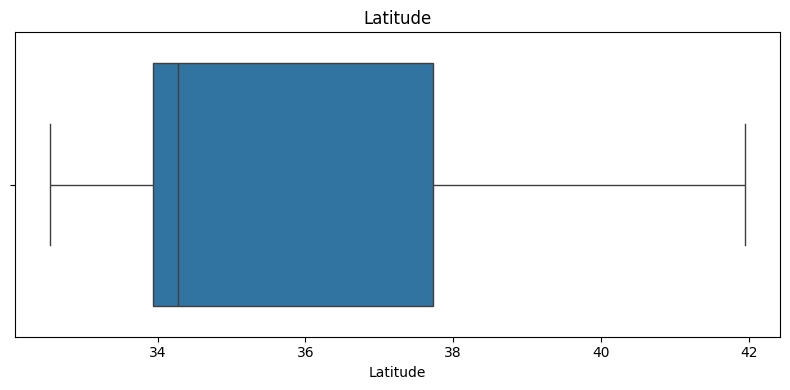

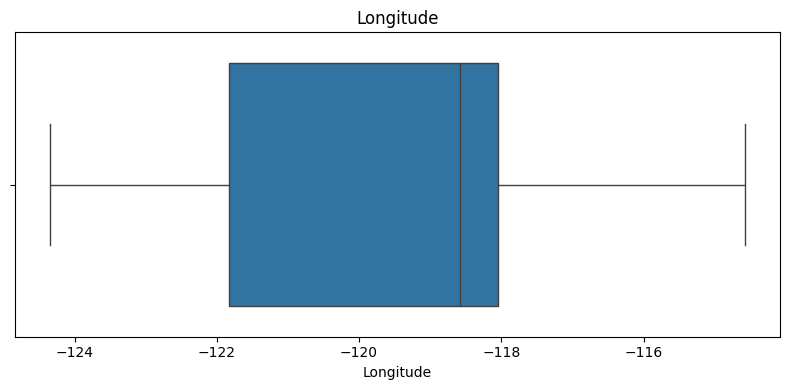

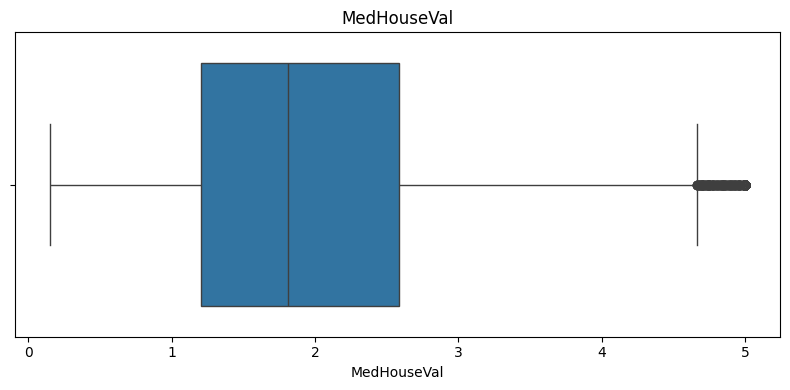

In [54]:
for col in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [48]:
Q1 = df['MedInc'].quantile(0.25)
Q3 = df['MedInc'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

df=df[(df['MedInc']>=lower) & (df['MedInc']<=upper)]

-0.7072000000000003
7.993600000000001


In [49]:
Q1 = df['AveRooms'].quantile(0.25)
Q3 = df['AveRooms'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

df=df[(df['AveRooms']>=lower) & (df['AveRooms']<=upper)]

2.128339577931115
8.243330649805635


In [50]:
Q1 = df['AveBedrms'].quantile(0.25)
Q3 = df['AveBedrms'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

df=df[(df['AveBedrms']>=lower) & (df['AveBedrms']<=upper)]

0.864399607305704
1.2368961602337745


In [53]:
Q1 = df['AveOccup'].quantile(0.25)
Q3 = df['AveOccup'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

df=df[(df['AveOccup']>=lower) & (df['AveOccup']<=upper)]

1.1441985297130912
4.567296908423866


In [55]:
from  sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X=df.drop('MedHouseVal',axis=1)
y=df['MedHouseVal']

scaler=StandardScaler()
X=scaler.fit_transform(X)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42)

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score



In [58]:
best_r2 = -float('inf')
best_n = None

for n in [20, 50, 100,200]:
  model = RandomForestRegressor(
      n_estimators=n,
      random_state=42
  )
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  r2_n = r2_score(y_test, y_pred)
  print(f"R2 Score for n={n} : {round(r2_n, 4)}")

  if r2_n > best_r2:
    best_r2 = r2_n
    best_n = n

print(f"\nBest N Estimators is selected {best_n} with R2 Score: {round(best_r2, 4)}")

R2 Score for n=20 : 0.7759
R2 Score for n=50 : 0.7834
R2 Score for n=100 : 0.786
R2 Score for n=200 : 0.7885

Best N Estimators is selected 200 with R2 Score: 0.7885


In [59]:
print('='*100)
print("Random Forest Regressor Performance")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

Random Forest Regressor Performance
R2 Score: 0.7885
Mean Squared Error: 0.2390


In [60]:
from sklearn.metrics import r2_score

# R²
r2 = r2_score(y_test, y_pred)

# Values
n = X_test.shape[0]
p = X_test.shape[1]

# Adjusted R²
adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("R² Score:", r2)
print("Adjusted R²:", adj_r2)

R² Score: 0.7884891400067066
Adjusted R²: 0.7881832674687553


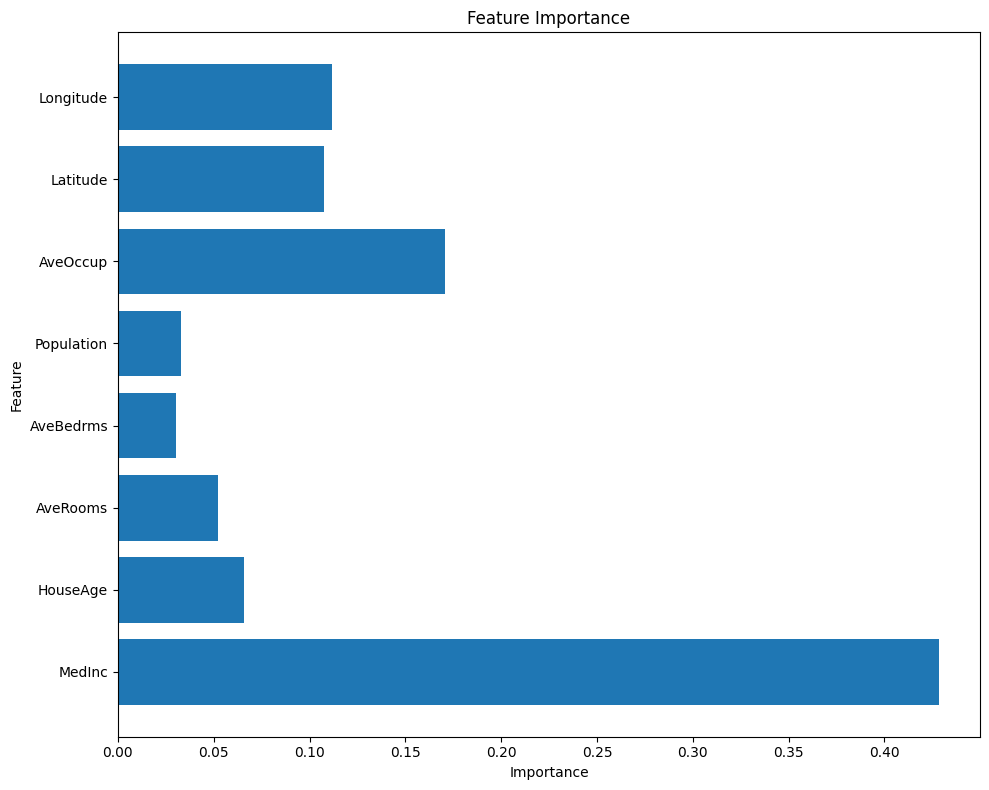

In [61]:
importance=model.feature_importances_
# Define feature_name using the column names from the California Housing DataFrame
feature_name = df.drop('MedHouseVal', axis=1).columns.tolist()

plt.figure(figsize=(10,8))
plt.barh(feature_name,importance)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [64]:
from google.colab import files

files.download('random_forest_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
!pip install scikit-learn==1.6.1

In [67]:
import joblib

model = joblib.load('random_forest_model.pkl')

print(model)

RandomForestClassifier(n_jobs=-1, random_state=42)
